---
format: 
    html:
        embed-resources: true
---


In [1]:
#import libraries
import pandas as pd
import numpy as np

In [2]:
#load the "rapid_transit_and_bus_prediction_accuracy_data.csv" file
#ride_accuracy = pd.read_csv("/Users/jenyanniguo/Documents/DSAN 5000/project-JenYanni/data/raw-data/rapid_transit_and_bus_prediction_accuracy_data.csv")
ride_accuracy = pd.read_csv("../../data/raw-data/rapid_transit_and_bus_prediction_accuracy_data.csv")

#convert csv file into a dataframe
ride_accuracy_df = pd.DataFrame(ride_accuracy)

#print the first 10 rows of dataframe
print(ride_accuracy_df.head(10))

#print shape of dataframe
print(ride_accuracy_df.shape)

       weekly mode route_id        bin arrival_departure  num_predictions  \
0  2020-08-06  bus      NaN    0-3 min         departure           233967   
1  2020-08-06  bus      NaN    3-6 min         departure           227406   
2  2020-08-06  bus      NaN   6-12 min         departure           445848   
3  2020-08-06  bus      NaN  12-30 min         departure          1261843   
4  2020-08-13  bus      NaN    0-3 min         departure           240187   
5  2020-08-13  bus      NaN    3-6 min         departure           233322   
6  2020-08-13  bus      NaN   6-12 min         departure           455828   
7  2020-08-13  bus      NaN  12-30 min         departure          1299411   
8  2020-08-20  bus      NaN    0-3 min         departure           234504   
9  2020-08-20  bus      NaN    3-6 min         departure           227992   

   num_accurate_predictions  
0                    183615  
1                    178297  
2                    368421  
3                   1101363  
4 

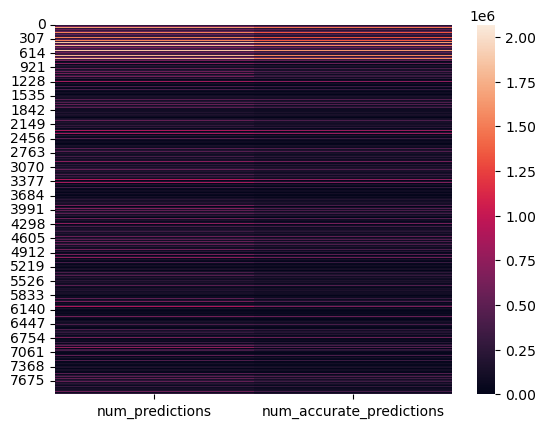

In [3]:
import seaborn as sns #import seaborn library
import matplotlib.pyplot as plt #import matplotlib.pyplot library

#subset dataframe to create a heatmap to visualize missing data. Keep numeric value columns
ride_accuracy_df_subset = ride_accuracy_df[[ "num_predictions", "num_accurate_predictions" ]]

#create heatmap of datafram before dropping NA values
sns.heatmap(ride_accuracy_df_subset)
plt.show() #show heatmap

       num_predictions  num_accurate_predictions
count     7.964000e+03              7.964000e+03
mean      2.411512e+05              1.988910e+05
std       2.944540e+05              2.492383e+05
min       0.000000e+00              0.000000e+00
25%       8.053400e+04              7.106275e+04
50%       1.306255e+05              1.100235e+05
75%       3.003818e+05              2.470378e+05
max       2.070137e+06              1.818970e+06


<Axes: >

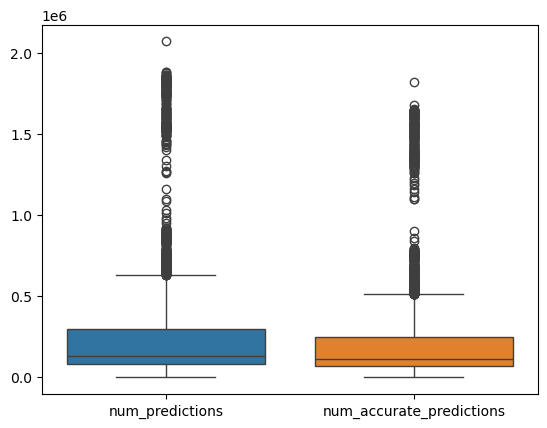

In [4]:
#find outliers before dropping na using describe()
print(ride_accuracy_df.describe())

#create boxplot of dataframe with na  to visualize outliers
sns.boxplot(data=ride_accuracy_df)

In [5]:
#find na values in the columns
ride_accuracy_df_na = ride_accuracy_df.isna().sum()
print(ride_accuracy_df_na)

#drop rows with NA values from the route_id column because it is the only column with na values
ride_accuracy_df_dropna = ride_accuracy_df
ride_accuracy_df_dropna.dropna(inplace=True)
print(ride_accuracy_df_dropna.shape)


weekly                        0
mode                          0
route_id                    780
bin                           0
arrival_departure             0
num_predictions               0
num_accurate_predictions      0
dtype: int64
(7184, 7)


In [6]:
#check the data types of columns
print(ride_accuracy_df_dropna.dtypes)

#convert "weekly" column data type to datetime
ride_accuracy_df_dropna["weekly"] = pd.to_datetime(ride_accuracy_df_dropna["weekly"])
#convert "mode" column data type to string
ride_accuracy_df_dropna["mode"] = ride_accuracy_df_dropna["mode"].astype(str)
#convert "route_id" column data type to string
ride_accuracy_df_dropna["route_id"] = ride_accuracy_df_dropna["route_id"].astype(str)
#convert "bin" column data type to string
ride_accuracy_df_dropna["bin"] = ride_accuracy_df_dropna["bin"].astype(str)
#convert "arrival_departure" column data type to string
ride_accuracy_df_dropna["arrival_departure"] = ride_accuracy_df_dropna["arrival_departure"].astype(str)

#check data types of columns after transformation
print(ride_accuracy_df_dropna.dtypes)


weekly                      object
mode                        object
route_id                    object
bin                         object
arrival_departure           object
num_predictions              int64
num_accurate_predictions     int64
dtype: object
weekly                      datetime64[ns]
mode                                object
route_id                            object
bin                                 object
arrival_departure                   object
num_predictions                      int64
num_accurate_predictions             int64
dtype: object


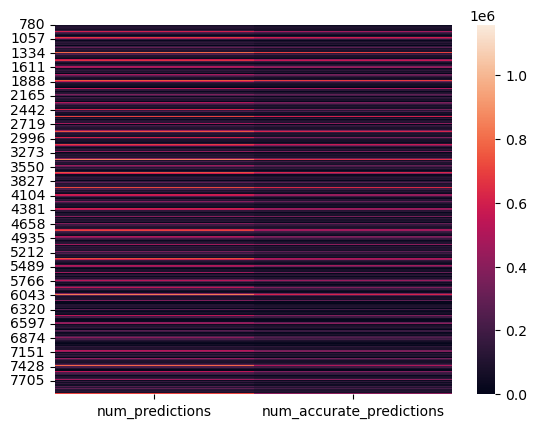

In [7]:
#subset dataframe to create a heatmap to visualize missing data. Keep numeric value columns
ride_accuracy_df_no_na_subset = ride_accuracy_df_dropna[[ "num_predictions", "num_accurate_predictions" ]]

#create heatmap of dataframe after dropping NA values
sns.heatmap(ride_accuracy_df_no_na_subset)
plt.show() #show heatmap

                              weekly  num_predictions  \
count                           7184     7.184000e+03   
mean   2022-09-09 15:45:18.040088832     1.900083e+05   
min              2020-08-03 00:00:00     0.000000e+00   
25%              2021-08-30 00:00:00     7.617800e+04   
50%              2022-09-26 00:00:00     1.199255e+05   
75%              2023-09-25 00:00:00     2.237600e+05   
max              2024-08-26 00:00:00     1.158573e+06   
std                              NaN     1.842277e+05   

       num_accurate_predictions  
count               7184.000000  
mean              154576.004176  
min                    0.000000  
25%                67576.000000  
50%               101258.000000  
75%               187399.250000  
max               904424.000000  
std               144457.231305  


<Axes: >

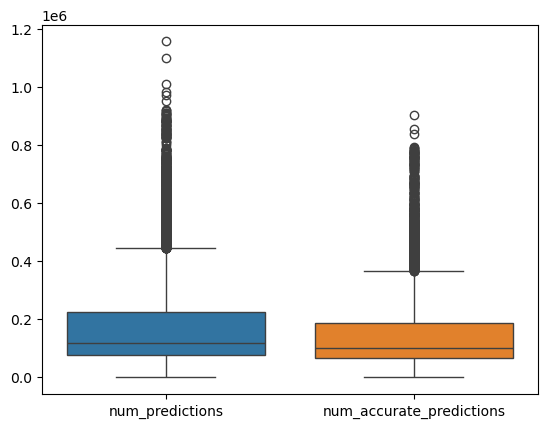

In [8]:
#find outliers after dropping na using describe()
print(ride_accuracy_df_dropna.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=ride_accuracy_df_dropna)

In [9]:
#split the "bin" column based on space character to separate the numerical range and the min unit
ride_accuracy_df_dropna[["a", "b"]] = ride_accuracy_df_dropna["bin"].str.split(" ", expand = True)
print(ride_accuracy_df_dropna.head())

#split the "a" column based on the "-" character to get a low range and high range of the bin values
ride_accuracy_df_dropna[["Low Range Bin Time (min)", "High Range Bin Time (min)"]] = ride_accuracy_df_dropna["a"].str.split("-", expand = True)
print(ride_accuracy_df_dropna.head())

#remove the unneeded "a" and "b" columns
ride_accuracy_df_drop_cols = ride_accuracy_df_dropna
ride_accuracy_df_drop_cols = ride_accuracy_df_drop_cols.drop(['a', 'b'], axis=1)
print(ride_accuracy_df_drop_cols.head(10))


        weekly    mode route_id        bin arrival_departure  num_predictions  \
780 2020-08-03  subway     Blue    0-3 min           blended            63612   
781 2020-08-03  subway     Blue    3-6 min           blended            65346   
782 2020-08-03  subway     Blue   6-12 min           blended           124158   
783 2020-08-03  subway     Blue  12-30 min           blended           350575   
784 2020-08-03  subway  Green-B    0-3 min           blended           144067   

     num_accurate_predictions      a    b  
780                     58116    0-3  min  
781                     58809    3-6  min  
782                    112668   6-12  min  
783                    314248  12-30  min  
784                    117550    0-3  min  
        weekly    mode route_id        bin arrival_departure  num_predictions  \
780 2020-08-03  subway     Blue    0-3 min           blended            63612   
781 2020-08-03  subway     Blue    3-6 min           blended            65346   
782 20

In [22]:
#export clean csv file to processed-data folder
ride_accuracy_df_drop_cols.to_csv("../../data/processed-data/Clean_Ride_Accuracy.csv")

In [10]:
from datetime import datetime #import datetime library for date conversion

#alternative analysis: add a column to the dataframe for binary classification target
ride_accuracy_df_binary = ride_accuracy_df_drop_cols

print(ride_accuracy_df_binary["weekly"].dtype) #check id column is datatime type

#we want to observe all dates after 2022-01-01 as "1"'s and all dates before 2022-01-01 as "0"'s
#split the data pre and post 2022-01-01 because that was the year the MBTA infrastructure renovation program began
date_to_string = "2022-01-01" #set variable to 2022-01-01 to find its numeric format
date_convert = datetime.strptime(date_to_string, "%Y-%m-%d") #convert string date to datetime format
print(type(date_convert)) #check if it is datetime format
num_date = int(date_convert.timestamp()) #convert datetime to an integer
#num_date_result = num_date//10**9
#print(num_date_result)
print(num_date) #print the numeric conversion of the 2022-01-01 date which equals 1641013200, easier for if else statement to transform dates into binary values


ride_accuracy_df_binary["Pre and Post 2021"] = ride_accuracy_df_binary["weekly"].astype('int64')//10**9 #convert dates in the "weekly" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(ride_accuracy_df_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

ride_accuracy_df_binary["Pre and Post 2021 Binary"] = np.where(ride_accuracy_df_binary["Pre and Post 2021"] > 1641013200, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(ride_accuracy_df_binary["Pre and Post 2021 Binary"].head()) #print first few rows of binary dates


datetime64[ns]
<class 'datetime.datetime'>
1641013200
780    1596412800
781    1596412800
782    1596412800
783    1596412800
784    1596412800
Name: Pre and Post 2021, dtype: int64
780    0
781    0
782    0
783    0
784    0
Name: Pre and Post 2021 Binary, dtype: int64


In [21]:
#export clean binary data csv file to processed-data folder
ride_accuracy_df_binary.to_csv("../../data/processed-data/Clean_Ride_Accuracy_Binary.csv")